In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')
from src_experiment.dataset import get_new_data

In [2]:
train, test = get_new_data("mnist_minimal_random")

Fetching mnist_minimal_random (torchvision)...
📉 Downsampling dataset to 25% of its original size...
⚠️ Overwriting targets with completely random labels (0-9)...


Images shape: torch.Size([32, 49])
Labels shape: torch.Size([32])


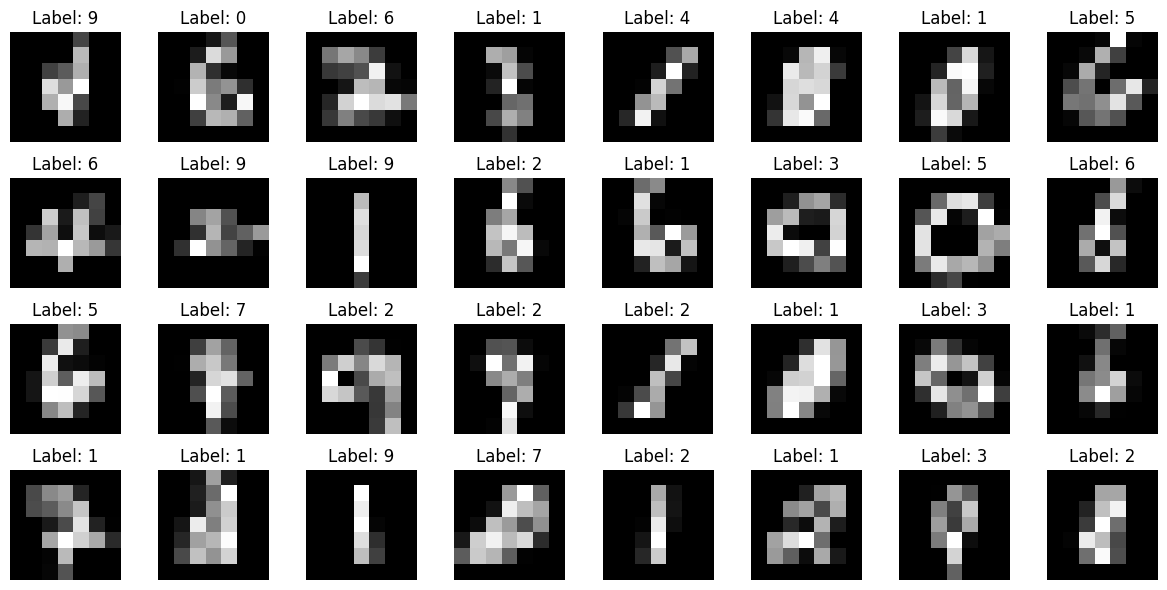

In [3]:
import matplotlib.pyplot as plt

# Get a batch of data
sample = next(iter(train))
images = sample[0]
labels = sample[1]

print(f"Images shape: {images.shape}")  # Shape of the input data
print(f"Labels shape: {labels.shape}")  # Shape of the labels   

# Function that displays the entire batch of 32 images
def display_batch(images, labels):
    # Create a 4x8 grid of subplots
    fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12, 6))
    
    # Flatten the axes array so we can iterate over it with a single loop
    axes = axes.flatten()
    
    for i in range(len(images)):
        ax = axes[i]
        
        # Squeeze removes single-dimensional entries from the shape (e.g., channels)
        image = images[i].reshape(7,7)
        
        # .item() gets the standard Python number from the tensor
        label = labels[i].item() 
        
        ax.imshow(image, cmap='gray')  # Display the image
        ax.set_title(f'Label: {label}')  # Display the label as title
        ax.axis('off')  # Hide axes
        
    # Adjust layout so titles don't overlap
    plt.tight_layout()
    plt.show()

# Call the function
display_batch(images, labels)

In [4]:
def verify_dataset_hypercube(dataloader):
    all_in_hypercube = True
    global_min = float('inf')
    global_max = float('-inf')

    for batch_idx, (images, _) in enumerate(dataloader):
        # Update global min and max
        batch_min = images.min().item()
        batch_max = images.max().item()
        
        if batch_min < global_min: global_min = batch_min
        if batch_max > global_max: global_max = batch_max

        # Check if this specific batch violates the boundaries
        if not ((images >= -1.0) & (images <= 1.0)).all():
            print(f"Violation found in batch {batch_idx}! Min: {batch_min}, Max: {batch_max}")
            all_in_hypercube = False
            
    print(f"--- Final Results ---")
    print(f"Global Minimum: {global_min}")
    print(f"Global Maximum: {global_max}")
    print(f"Entire dataset in unit hypercube: {all_in_hypercube}")

# Run the check on your train dataset
verify_dataset_hypercube(train)

--- Final Results ---
Global Minimum: -1.0
Global Maximum: 1.0
Entire dataset in unit hypercube: True


In [ ]:
# Train model

from src_experiment.utils import NeuralNet
from src_experiment.train_models import train_model_multiclass

model = NeuralNet(49, [100,100,100,100], 10, seed=0)


res = train_model_multiclass(model, train, test, 501, sgd_lr=0.01)

Training not saved.


In [25]:
res

(     train_loss  train_accuracy  test_loss  test_accuracy  eval_train_loss  \
 0      2.330045        0.102500   2.307712          0.106         2.301511   
 1      2.303981        0.110833   2.311817          0.101         2.298316   
 2      2.301015        0.112500   2.312759          0.078         2.293070   
 3      2.298100        0.114833   2.314044          0.085         2.296030   
 4      2.298175        0.114667   2.315764          0.085         2.291134   
 ..          ...             ...        ...            ...              ...   
 246    1.058924        0.667000   6.976896          0.108         0.935579   
 247    0.907694        0.704333   7.927442          0.110         0.835022   
 248    0.916805        0.698333   7.645663          0.129         0.862036   
 249    0.904460        0.695833   7.955228          0.126         0.680745   
 250    0.868550        0.711167   8.433591          0.115         0.739494   
 
      eval_train_accuracy  
 0               0.113